In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from astropy.table import Table
import read_mist_models

In [14]:
galah_pd = (Table.read('../../lithium/data/GALAH_DR3_main_allstar_v2.fits',format='fits')).to_pandas()

In [29]:
table4 = pd.read_csv('table4_new.csv')

In [3]:
rv_df = pd.read_csv('rv_df_new.csv')

In [5]:
binary_list_113 = [9, 11, 16, 18, 19, 23,] # old: 1, 4, 5, 7, 9, 11, 16, 18, 19, 21, 23  
binary_list_112 = [6, 7, 23] #old: 5, 6, 7, 23 #13 removed because of dipper star
binary_list_116 = [17] 


In [33]:
t1 = rv_df[(rv_df.program==112) & (rv_df.RG_id.isin(binary_list_112))]
t2 = rv_df[(rv_df.program==113) & (rv_df.RG_id.isin(binary_list_113))]
t3 = rv_df[(rv_df.program==116) & (rv_df.RG_id.isin(binary_list_116))]
table = pd.concat([t1, t2, t3])
table = pd.merge(galah_pd[['sobject_id','alpha_fe']], table4, left_on='sobject_id', right_on='sobject_id')

#

In [27]:
mist_files = glob.glob('../MIST_EEP/*.txz')
import tarfile

# np.loadtxt(mist_files[0])


with tarfile.open(mist_files[0], mode='r:xz') as tar:
    tar.extractall(path='../MIST_EEP')

In [87]:
table[['sobject_id','teff','logg','Li_val','fe_h','alpha_fe','m_act_bstep']]

eep_files = {
    140209002201006: '../MIST_EEP/feh_p000_afe_p4_vvcrit0.0/eeps/00160M.track.eep',
    140707003101315: '../MIST_EEP/feh_m075_afe_p2_vvcrit0.0/eeps/00095M.track.eep',
    150829004301285: '../MIST_EEP/feh_m050_afe_p2_vvcrit0.0/eeps/00165M.track.eep',
    160129003601260: '../MIST_EEP/feh_m025_afe_p0_vvcrit0.0/eeps/00190M.track.eep',
    160524006101130: '../MIST_EEP/feh_m050_afe_p2_vvcrit0.0/eeps/00170M.track.eep',
    170418005701333: '../MIST_EEP/feh_m025_afe_p2_vvcrit0.0/eeps/00125M.track.eep',
    170509005201208: '../MIST_EEP/feh_p025_afe_p0_vvcrit0.0/eeps/00200M.track.eep',
    170514002101318: '../MIST_EEP/feh_p000_afe_m2_vvcrit0.0/eeps/00180M.track.eep',
    170615003401088: '../MIST_EEP/feh_m025_afe_p2_vvcrit0.0/eeps/00105M.track.eep',
    170615003401088: '../MIST_EEP/feh_m025_afe_p4_vvcrit0.0/eeps/00105M.track.eep',
    170801002501304: '../MIST_EEP/feh_p000_afe_p0_vvcrit0.0/eeps/00160M.track.eep'
}

In [73]:
file = '../MIST_EEP/feh_p000_afe_p4_vvcrit0.0/eeps/00160M.track.eep'
eep = read_mist_models.EEP(file)
print('FeH: ', eep.abun['[Fe/H]'])
print('a/Fe: ', eep.abun['[a/Fe]'])
print('mass: ', eep.minit)

# eep.plot_HR(color='Black', phases=[0, 6], phasecolor=['Red', 'Blue'])
# Following the FSPS notation, PMS:-1 ; MS:0 ; SGB+RGB:2 ; CHeB:3 ; EAGB:4 ; TPAGB:5 ; post-AGB:6 ; WR:9

Reading in: ../MIST_EEP/feh_p000_afe_p4_vvcrit0.0/eeps/00160M.track.eep
FeH:  0.0
a/Fe:  0.4
mass:  1.6


Reading in: ../MIST_EEP/feh_p000_afe_p4_vvcrit0.0/eeps/00160M.track.eep
Galah FeH: -0.10 MIST FeH:  0.0
Galah a/Fe: 0.33 MIST a/Fe:  0.4
Galah Mass: 1.59 MIST Mass:  1.6
1


<ipython-input-91-f32406e2902d>:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Galah FeH: %.2f' % d['fe_h'],'MIST FeH: ', eep.abun['[Fe/H]'])
<ipython-input-91-f32406e2902d>:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Galah a/Fe: %.2f' % d['alpha_fe'],'MIST a/Fe: ', eep.abun['[a/Fe]'])
<ipython-input-91-f32406e2902d>:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Galah Mass: %.2f' % d['m_act_bstep'],'MIST Mass: ', eep.minit)


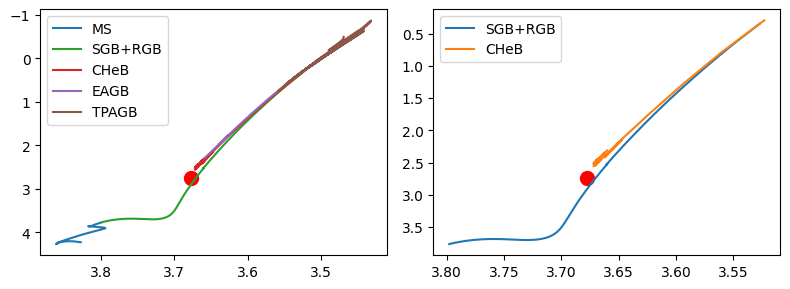

Reading in: ../MIST_EEP/feh_m075_afe_p2_vvcrit0.0/eeps/00095M.track.eep
Galah FeH: -0.80 MIST FeH:  -0.75
Galah a/Fe: 0.26 MIST a/Fe:  0.2
Galah Mass: 0.96 MIST Mass:  0.95
1


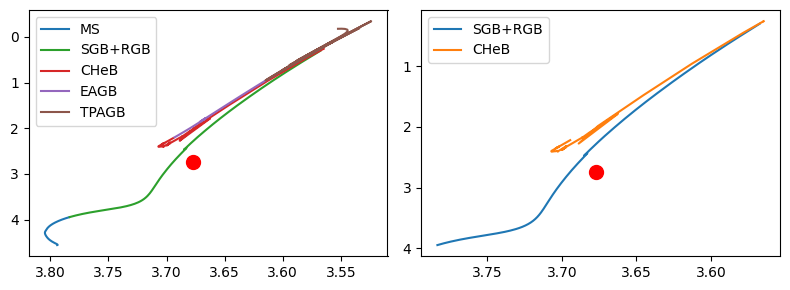

Reading in: ../MIST_EEP/feh_m050_afe_p2_vvcrit0.0/eeps/00165M.track.eep
Galah FeH: -0.42 MIST FeH:  -0.5
Galah a/Fe: 0.23 MIST a/Fe:  0.2
Galah Mass: 1.67 MIST Mass:  1.65
1


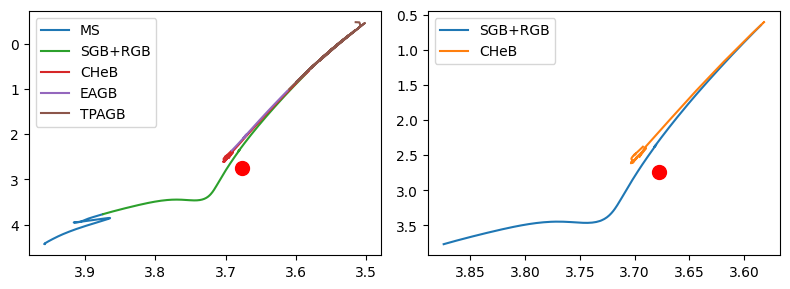

Reading in: ../MIST_EEP/feh_m025_afe_p0_vvcrit0.0/eeps/00190M.track.eep
Galah FeH: -0.21 MIST FeH:  -0.25
Galah a/Fe: 0.01 MIST a/Fe:  0.0
Galah Mass: 1.89 MIST Mass:  1.9
1


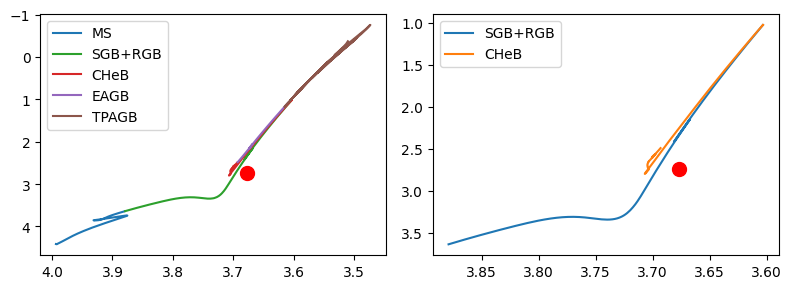

Reading in: ../MIST_EEP/feh_m050_afe_p2_vvcrit0.0/eeps/00170M.track.eep
Galah FeH: -0.41 MIST FeH:  -0.5
Galah a/Fe: 0.21 MIST a/Fe:  0.2
Galah Mass: 1.73 MIST Mass:  1.7
1


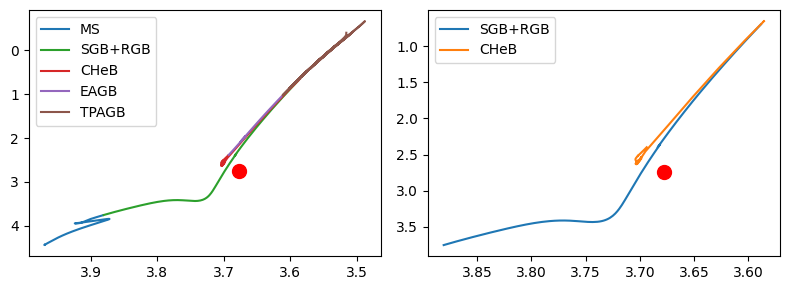

Reading in: ../MIST_EEP/feh_m025_afe_p2_vvcrit0.0/eeps/00125M.track.eep
Galah FeH: -0.21 MIST FeH:  -0.25
Galah a/Fe: 0.23 MIST a/Fe:  0.2
Galah Mass: 1.24 MIST Mass:  1.25
1


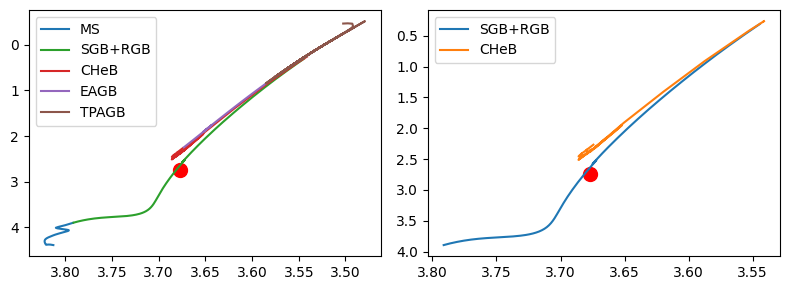

Reading in: ../MIST_EEP/feh_p025_afe_p0_vvcrit0.0/eeps/00200M.track.eep
Galah FeH: 0.36 MIST FeH:  0.25
Galah a/Fe: 0.06 MIST a/Fe:  0.0
Galah Mass: 1.99 MIST Mass:  2.0
1


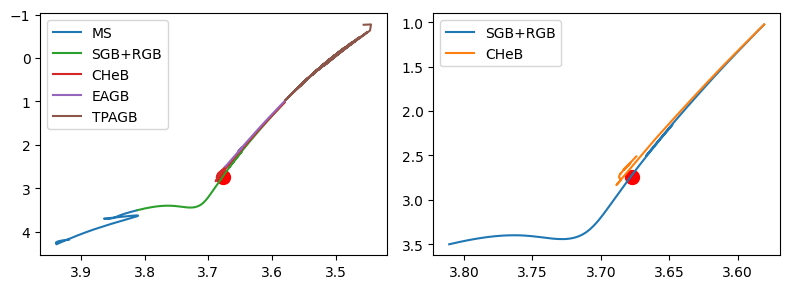

Reading in: ../MIST_EEP/feh_p000_afe_m2_vvcrit0.0/eeps/00180M.track.eep
Galah FeH: 0.06 MIST FeH:  0.0
Galah a/Fe: -0.17 MIST a/Fe:  -0.2
Galah Mass: 1.80 MIST Mass:  1.8
1


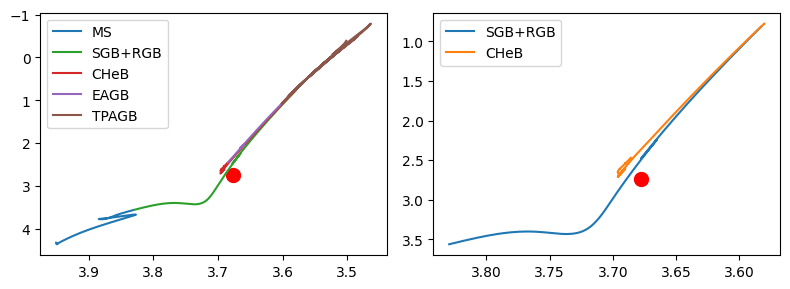

Reading in: ../MIST_EEP/feh_m025_afe_p4_vvcrit0.0/eeps/00105M.track.eep
Galah FeH: -0.28 MIST FeH:  -0.25
Galah a/Fe: 0.31 MIST a/Fe:  0.4
Galah Mass: 1.06 MIST Mass:  1.05
1


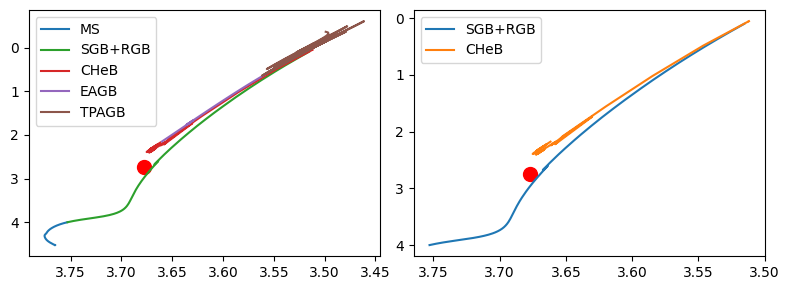

Reading in: ../MIST_EEP/feh_p000_afe_p0_vvcrit0.0/eeps/00160M.track.eep
Galah FeH: 0.03 MIST FeH:  0.0
Galah a/Fe: 0.01 MIST a/Fe:  0.0
Galah Mass: 1.61 MIST Mass:  1.6
1


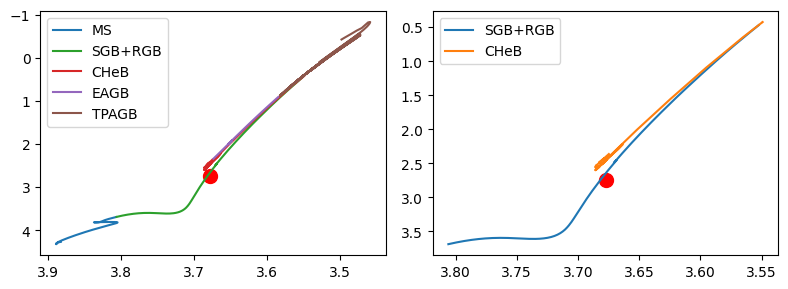

In [91]:
def _():
    for star, fname in eep_files.items():
        eep = read_mist_models.EEP(fname)
        phase_labels = {-1: 'PMS', 1:'', 0:'MS', 2:'SGB+RGB', 3:'CHeB', 4:'EAGB', 5:'TPAGB', 6:'post-AGB',9:'WR'}
        d = table[table.sobject_id==star]
        print('Galah FeH: %.2f' % d['fe_h'],'MIST FeH: ', eep.abun['[Fe/H]'])
        print('Galah a/Fe: %.2f' % d['alpha_fe'],'MIST a/Fe: ', eep.abun['[a/Fe]'])
        print('Galah Mass: %.2f' % d['m_act_bstep'],'MIST Mass: ', eep.minit)
        
        plt.figure(figsize=(8,3),dpi=100)
        plt.subplot(121)
        for phase in range(0,6):
            if phase ==1 : print(phase)
            idx = (eep.eeps['phase'] == phase)
            plt.plot(eep.eeps['log_Teff'][idx],eep.eeps['log_g'][idx],label=phase_labels[phase])
        plt.gca().invert_xaxis()
        plt.gca().invert_yaxis()
        plt.scatter(np.log10(4757.1543),2.742036,c='r',s=100)
        plt.legend()

        plt.subplot(122)

        for phase in [2,3]:
            idx = (eep.eeps['phase'] == phase)
            plt.plot(eep.eeps['log_Teff'][idx],eep.eeps['log_g'][idx],label=phase_labels[phase])
        plt.scatter(np.log10(4757.1543),2.742036,c='r',s=100)
        plt.gca().invert_xaxis()
        plt.gca().invert_yaxis()
        plt.legend()

        plt.tight_layout()
        plt.show()
_()    

1


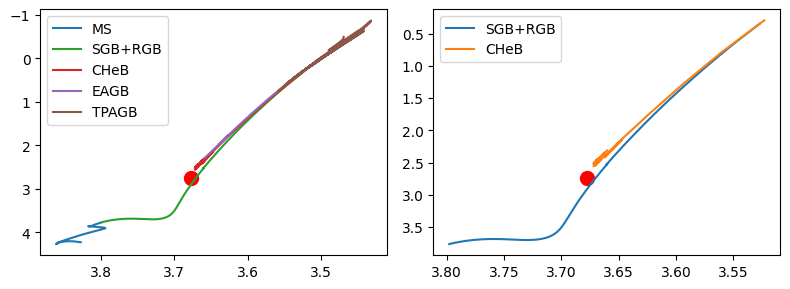

In [86]:
phase_labels = {-1: 'PMS', 1:'', 0:'MS', 2:'SGB+RGB', 3:'CHeB', 4:'EAGB', 5:'TPAGB', 6:'post-AGB',9:'WR'}

plt.figure(figsize=(8,3),dpi=100)
plt.subplot(121)
for phase in range(0,6):
    if phase ==1 : print(phase)
    idx = (eep.eeps['phase'] == phase)
    plt.plot(eep.eeps['log_Teff'][idx],eep.eeps['log_g'][idx],label=phase_labels[phase])
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.scatter(np.log10(4757.1543),2.742036,c='r',s=100)
plt.legend()

plt.subplot(122)

for phase in [2,3]:
    idx = (eep.eeps['phase'] == phase)
    plt.plot(eep.eeps['log_Teff'][idx],eep.eeps['log_g'][idx],label=phase_labels[phase])
plt.scatter(np.log10(4757.1543),2.742036,c='r',s=100)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()

plt.tight_layout()